In [5]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data, load_txt_polars

import os
os.chdir(project_root)

df = load_illness_data("SCZ", in_notebook=True, distribution="low", p_value=0.001)
#df_significant =  load_txt_polars(data_path="../../data/sampled/low/sampled_SCZ_p0.0001_significant.txt", sep="\t")


Starting to load ./data/sampled/low/sampled_SCZ_p0.001.txt with pandas...
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled/low/sampled_SCZ_p0.001_significant_rows_p0.05.txt with Polars...
Loading sampled_SCZ_p0.001_significant_rows_p0.05.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.001_significant_rows_p0.05.txt with Polars. Total rows: 5249
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled/low/sampled_SCZ_p0.001_significant_columns_p0.05.txt with Polars...
Loading sampled_SCZ_p0.001_significant_columns_p0.05.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.001_significant_columns_p0.05.txt with Polars. Total rows: 1010
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled_p/low/sampled_SCZ_p0.001.txt with Polars...
Loading sampled_SCZ_p0.001.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.001.txt with Polars. Total rows: 52

In [ ]:
# sort the rows by number of significant p values over all columns except the first two

df_significant = df_significant.sort_values(by="significant_count", ascending=True)

#df_sorted = df_sorted.drop(columns=["significant_count"])

In [ ]:
df_significant

,ID,significant_count
1940,rs2975923,8
1939,rs11853442,12
1938,rs28821644,12
1937,rs508161,13
1936,rs1456264,13
...,...,...
4,rs2960000,777
3,rs1631850,804
2,rs1378358,826
1,rs77804065,830


In [ ]:
# only take top 200 IDs from df_sorted of df
significant = df_significant.head(1700)
df_significant = df[df["ID"].isin(significant["ID"])]

In [6]:
X = df_significant.drop(columns=["Z", "ID"]).values
y = df_significant["Z"].values

NameError: name 'df_significant' is not defined

In [ ]:
# shape of X and y
print(X.shape)
print(y.shape)

(1700, 1010)
(1700,)


In [ ]:
# write a script that inverts all features where the label is negative
import numpy as np

for i in range(X.shape[1]):
    X[:, i] = np.where(y.flatten() < 0, -X[:, i], X[:, i])
    # also change the label to positive for those samples


y = np.where(y.flatten() < 0, -y.flatten(), y.flatten()).reshape(-1, 1)

In [2]:
# box cox transformation on target
from scipy import stats
#y, _ = stats.boxcox(y.flatten() + 1)  # add 1 to avoid issues with zero or negative values
y = y.reshape(-1, 1)

# do the inverse cube
y = np.cbrt(y)

NameError: name 'y' is not defined

In [3]:
# plot distribution of labels
import matplotlib.pyplot as plt
plt.hist(y, bins=20)
plt.title("Distribution of Labels (Z)")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.show()

NameError: name 'y' is not defined

In [4]:
# sample from two different normal distributions with different means and variances
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split


from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr


 
# implement cross validation with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # scale the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # scale the y values
    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(y_train)
    y_test = y_scaler.transform(y_test)

    linear = LinearRegression()
    linear.fit(X_train, y_train)
    y_pred_linear = linear.predict(X_test)

    # correlation between y_test and y_pred_linear
    correlation_linear, p_value = pearsonr(y_test.flatten(), y_pred_linear.flatten())
    print(f"Correlation between y_test and y_pred_linear: {correlation_linear**2}")
    print(f"P-value: {p_value}")

    # print the distribution of y_pred_linear
    plt.hist(y_pred_linear, bins=20)
    plt.title("Distribution of Predicted Labels (Linear Regression)")
    plt.xlabel("Predicted Z")
    plt.ylabel("Frequency")
    plt.show()  

    # print distribution of residuals
    residuals = y_test.flatten() - y_pred_linear.flatten()
    plt.hist(residuals, bins=20)        
    plt.title("Distribution of Residuals (Linear Regression)")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()  


    # print scatter of residuals vs predicted values
    plt.scatter(y_pred_linear, residuals)
    plt.title("Residuals vs Predicted Values (Linear Regression)")
    plt.xlabel("Predicted Z")
    plt.ylabel("Residual")
    plt.show()  

    # create qq plot of residuals
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals.flatten(), dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals - Linear Regression")
    plt.show()   

    

NameError: name 'X' is not defined

In [229]:
def cv(X, y, model, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    correlations = []
    p_values = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # scale the features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # scale the y values
        y_scaler = StandardScaler()
        y_train = y_scaler.fit_transform(y_train)
        y_test = y_scaler.transform(y_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        correlation, p_value = pearsonr(y_test.flatten(), y_pred.flatten())
        correlations.append(correlation**2)
        p_values.append(p_value)

    return correlations, p_values

In [230]:
# write a function 
def get_significant(df, df_significant_rows, df_significant_cols, row_ratio=0.5, col_ratio = 0.1):
    #df = load_illness_data(illness=illness, in_notebook=True, distribution="low", p_value=p_value)
    #df_significant_ =  load_txt_polars(data_path="../../data/sampled/low/sampled_" + illness + "_p" + str(p_value) + "_significant.txt", sep="\t")
    #df_significant_cols = load_txt_polars(data_path="../../data/sampled/low/sampled_" + illness + "_p" + str(p_value) + "_significant_columns.txt", sep="\t")

    df_significant_rows = df_significant_rows.sort_values(by="significant_count", ascending=False)
    df_significant_cols = df_significant_cols.sort_values(by="significant_count", ascending=False)

    top = int(len(df_significant_rows) * row_ratio)
    top_cols = int(len(df_significant_cols) * col_ratio)
    significant = df_significant_rows.head(top)
    significant_cols = df_significant_cols.head(top_cols)

    significant_cols = significant_cols.reset_index(drop=True)
    top_features_list = significant_cols.iloc[:, 0].tolist()

    df_top = df[df["ID"].isin(significant["ID"])]
    rows_to_keep = ["ID", "Z"] + top_features_list
    
    df_top= df_top[rows_to_keep]

    low = len(df_significant_rows) - top
    non_significant = df_significant_rows.tail(low)
    df_non_significant = df[df["ID"].isin(non_significant["ID"])]
    df_non_significant = df_non_significant[rows_to_keep]

    return df_top, df_non_significant

In [234]:

results = {}
illness = "SCZ"
p_value = 0.0001
df = load_illness_data(illness=illness, in_notebook=True, distribution="low", p_value=p_value)
df_significant =  load_txt_polars(data_path="../../data/sampled/low/sampled_" + illness + "_p" + str(p_value) + "_significant_rows_p0.05.txt", sep="\t")
df_significant_cols = load_txt_polars(data_path="../../data/sampled/low/sampled_" + illness + "_p" + str(p_value) + "_significant_columns_p0.05.txt", sep="\t")


for row_ratio in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:

    correlations_top_list = []
    p_values_top_list = []
    correlations_low_list = []
    p_values_low_list = []


    print(f"Starting Row Ratio: {row_ratio}")
    for col_ratio in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
        df_top, df_non_significant = get_significant(df, df_significant, df_significant_cols, row_ratio=row_ratio, col_ratio=col_ratio)
        
        # print the shape of df_top and df_non_significant
        #print(f"Shape of df_top: {df_top.shape}")
        #print(f"Shape of df_non_significant: {df_non_significant.shape}")
        X_top = df_top.drop(columns=["Z", "ID"]).values
        y_top = df_top["Z"].values
        y_top = y_top.reshape(-1, 1)

        X_low = df_non_significant.drop(columns=["Z", "ID"]).values
        y_low = df_non_significant["Z"].values
        y_low = y_low.reshape(-1, 1)
        model = LinearRegression()
        correlations_top, p_values_top = cv(X_top, y_top, model)
        correlations_top_list.append(np.mean(correlations_top))
        p_values_top_list.append(np.mean(p_values_top))

        #correlations_low, p_values_low = cv(X_low, y_low, model)
        #correlations_low_list.append(np.mean(correlations_low))
        #p_values_low_list.append(np.mean(p_values_low))

    # print nicely in a table
    import pandas as pd
    results_df = pd.DataFrame({
        "Ratio": [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
        "Correlation Top": correlations_top_list,
        "P-value Top": p_values_top_list,
        #"Correlation Low": correlations_low_list,
        #"P-value Low": p_values_low_list
    })

    results[row_ratio] = results_df

Loading data for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.0001.txt
Starting to load ../../data/sampled/low/sampled_SCZ_p0.0001.txt with pandas...


Loading sampled_SCZ_p0.0001.txt:  88%|████████▊ | 15.7M/17.9M [00:00<00:00, 19.7MB/s]


Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled/low/sampled_SCZ_p0.0001_significant_rows_p0.05.txt with Polars...
Loading sampled_SCZ_p0.0001_significant_rows_p0.05.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.0001_significant_rows_p0.05.txt with Polars. Total rows: 1941
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled/low/sampled_SCZ_p0.0001_significant_columns_p0.05.txt with Polars...
Loading sampled_SCZ_p0.0001_significant_columns_p0.05.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.0001_significant_columns_p0.05.txt with Polars. Total rows: 1010
Starting Row Ratio: 0.05
Starting Row Ratio: 0.1
Starting Row Ratio: 0.2
Starting Row Ratio: 0.3
Starting Row Ratio: 0.4
Starting Row Ratio: 0.5
Starting Row Ratio: 0.6
Starting Row Ratio: 0.7
Starting Row Ratio: 0.8
Starting Row Ratio: 0.9
Starting Row Ratio: 1


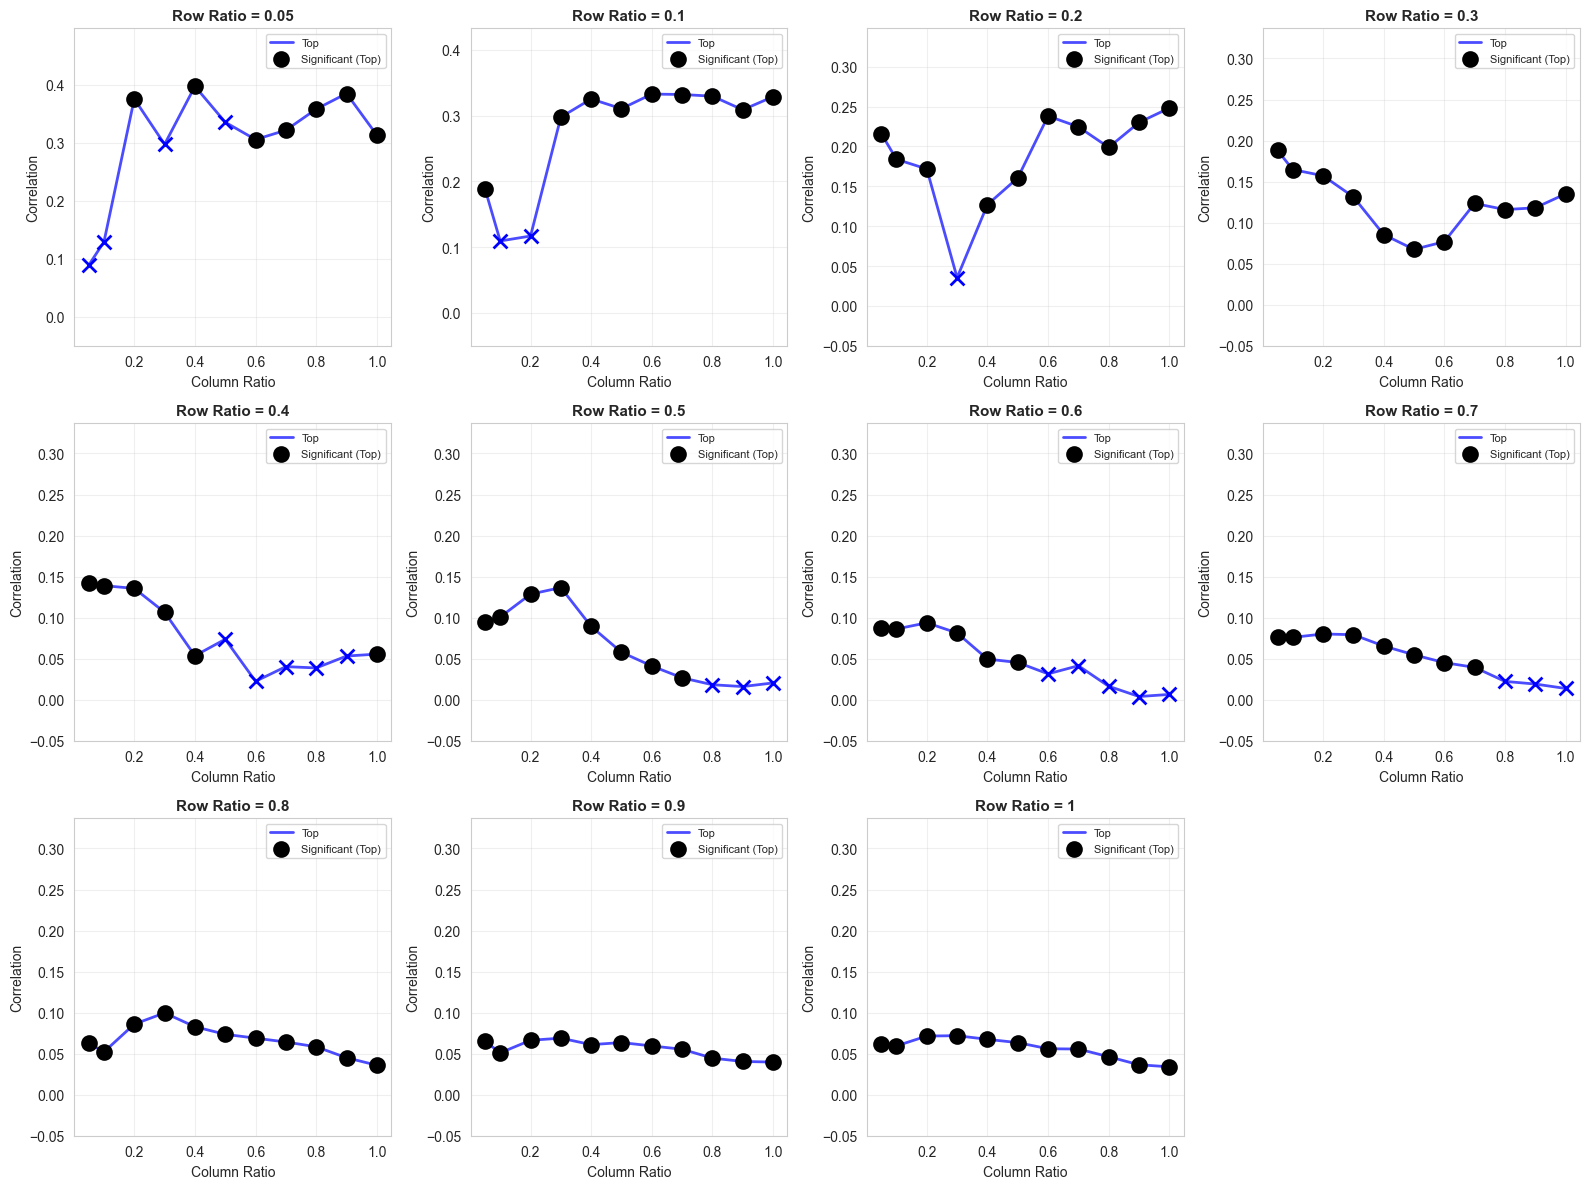

In [235]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with subplots for each row_ratio
row_ratios = sorted(results.keys())
n_rows = 3
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, row_ratio in enumerate(row_ratios):
    ax = axes[idx]
    df_results = results[row_ratio]
    
    col_ratios = df_results["Ratio"].values
    corr_top = df_results["Correlation Top"].values
    p_top = df_results["P-value Top"].values
    #corr_low = df_results["Correlation Low"].values
    #p_low = df_results["P-value Low"].values
    
    # Plot correlations as connected lines
    ax.plot(col_ratios, corr_top, 'b-', label="Top", linewidth=2, alpha=0.7)
    #ax.plot(col_ratios, corr_low, 'r-', label="Low", linewidth=2, alpha=0.7)
    
    # Mark significant correlations (p < 0.05) with black circles
    # Top significant
    mask_sig_top = p_top < 0.05
    ax.scatter(col_ratios[mask_sig_top], corr_top[mask_sig_top], 
               marker='o', s=100, color='black', edgecolors='black', 
               linewidths=2, zorder=5, label="Significant (Top)" if mask_sig_top.any() else "")
    
    # Low significant
    #mask_sig_low = p_low < 0.05
    #ax.scatter(col_ratios[mask_sig_low], corr_low[mask_sig_low], 
    #           marker='o', s=100, color='black', edgecolors='black', 
    #           linewidths=2, zorder=5, label="Significant (Low)" if mask_sig_low.any() else "")
    
    # Mark non-significant correlations (p >= 0.05) with crosses
    # Top non-significant
    mask_nonsig_top = p_top >= 0.05
    ax.scatter(col_ratios[mask_nonsig_top], corr_top[mask_nonsig_top], 
               marker='x', s=100, color='blue', linewidths=2, zorder=5)
    
    # Low non-significant
    #mask_nonsig_low = p_low >= 0.05
    #ax.scatter(col_ratios[mask_nonsig_low], corr_low[mask_nonsig_low], 
    #           marker='x', s=100, color='red', linewidths=2, zorder=5)
    
    ax.set_xlabel("Column Ratio", fontsize=10)
    ax.set_ylabel("Correlation", fontsize=10)
    ax.set_title(f"Row Ratio = {row_ratio}", fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    ax.set_ylim([-0.05, max(corr_top.max(), corr_low.max()) + 0.1])

# Remove extra subplots
for idx in range(len(row_ratios), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [16]:
df = load_illness_data("SCZ", in_notebook=True, distribution="low", p_value=0.0001)
X = df.drop(columns=["Z", "ID"]).values
y = df["Z"].values

Loading data for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.0001.txt
Starting to load ../../data/sampled/low/sampled_SCZ_p0.0001.txt with pandas...


Loading sampled_SCZ_p0.0001.txt:  88%|████████▊ | 15.7M/17.9M [00:00<00:00, 22.3MB/s]


In [ ]:
# sample from two different normal distributions with different means and variances
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split


from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
 
pearson_correlations = []
r2 = []
# implement cross validation with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linear = LinearRegression()
    linear.fit(X_train_scaled, y_train)
    y_pred_linear = linear.predict(X_test_scaled)
    
    # correlation between y_test and y_pred_linear
    r2 = linear.score(X_test_scaled, y_test)
    correlation_linear, p_value = pearsonr(y_test.flatten(), y_pred_linear.flatten())
    print(f"Correlation between y_test and y_pred_linear: {correlation_linear**2}")
    print(f"P-value: {p_value}")

Correlation between y_test and y_pred_linear: 0.033163937869033336
P-value: 0.00030567670682189063
Correlation between y_test and y_pred_linear: 0.013908227035377864
P-value: 0.020145188294223276
Correlation between y_test and y_pred_linear: 0.030304898011576722
P-value: 0.0005725204096940458
Correlation between y_test and y_pred_linear: 0.06379750939699659
P-value: 4.626191823567232e-07
Correlation between y_test and y_pred_linear: 0.02863648179810158
P-value: 0.0008177280325546122


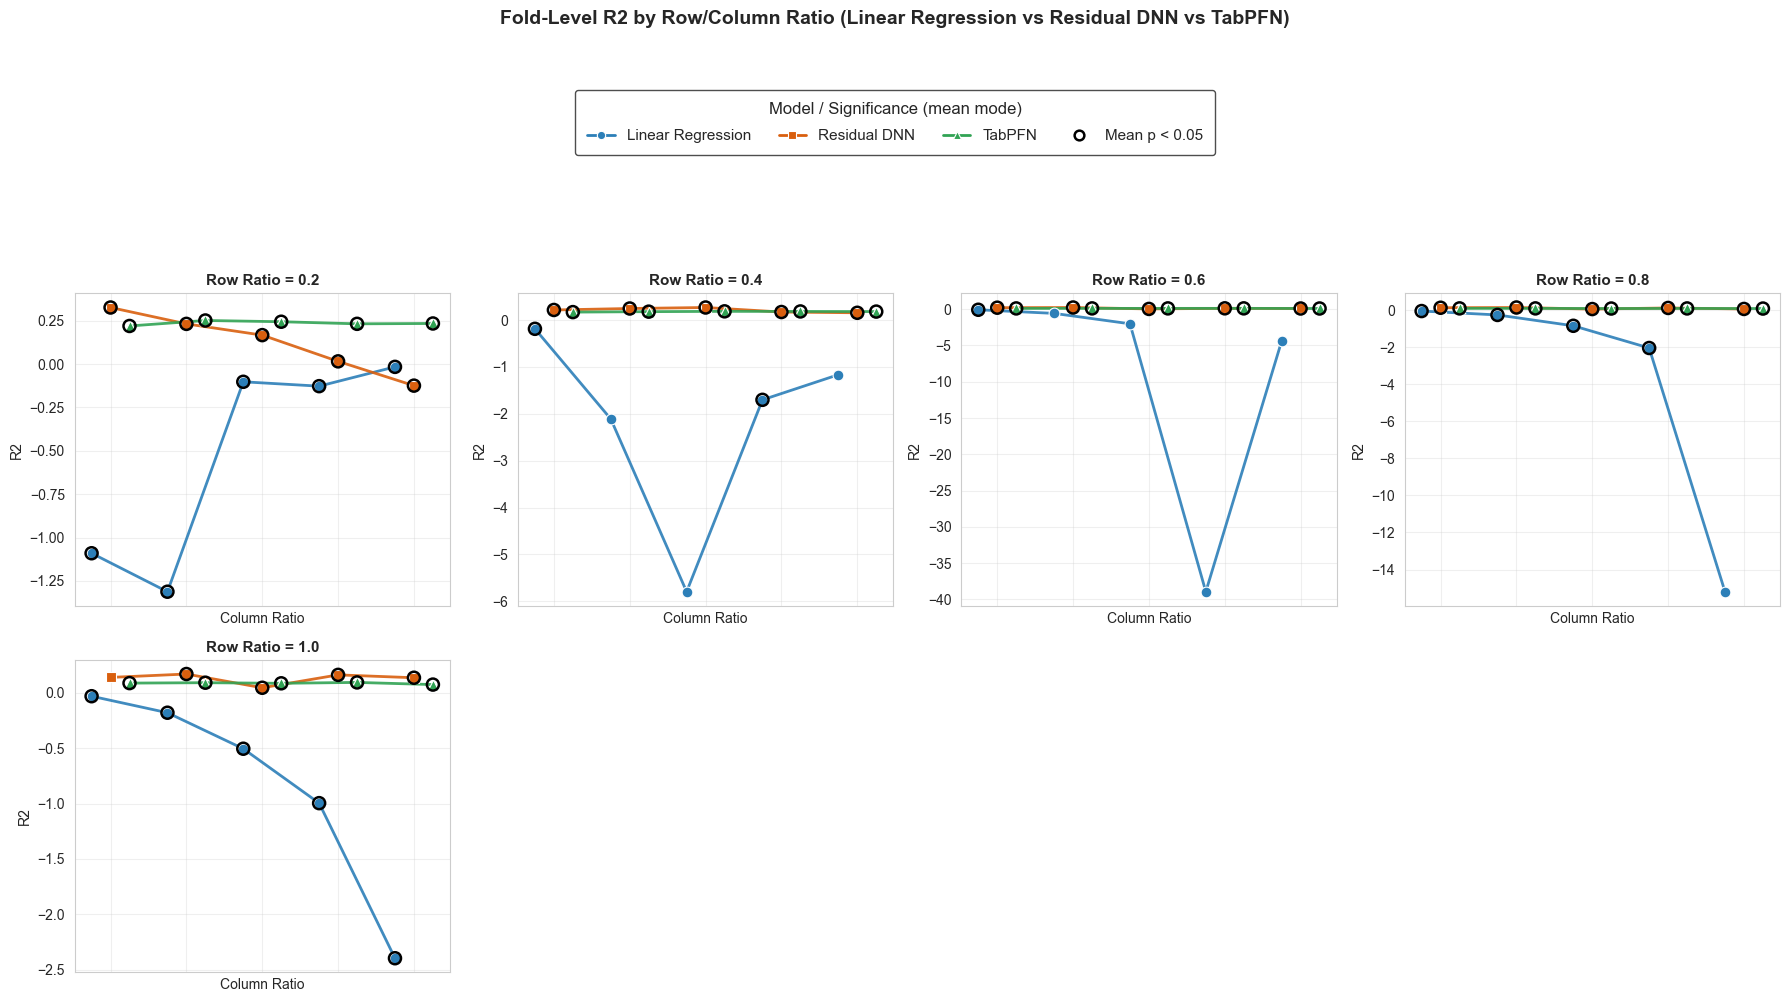

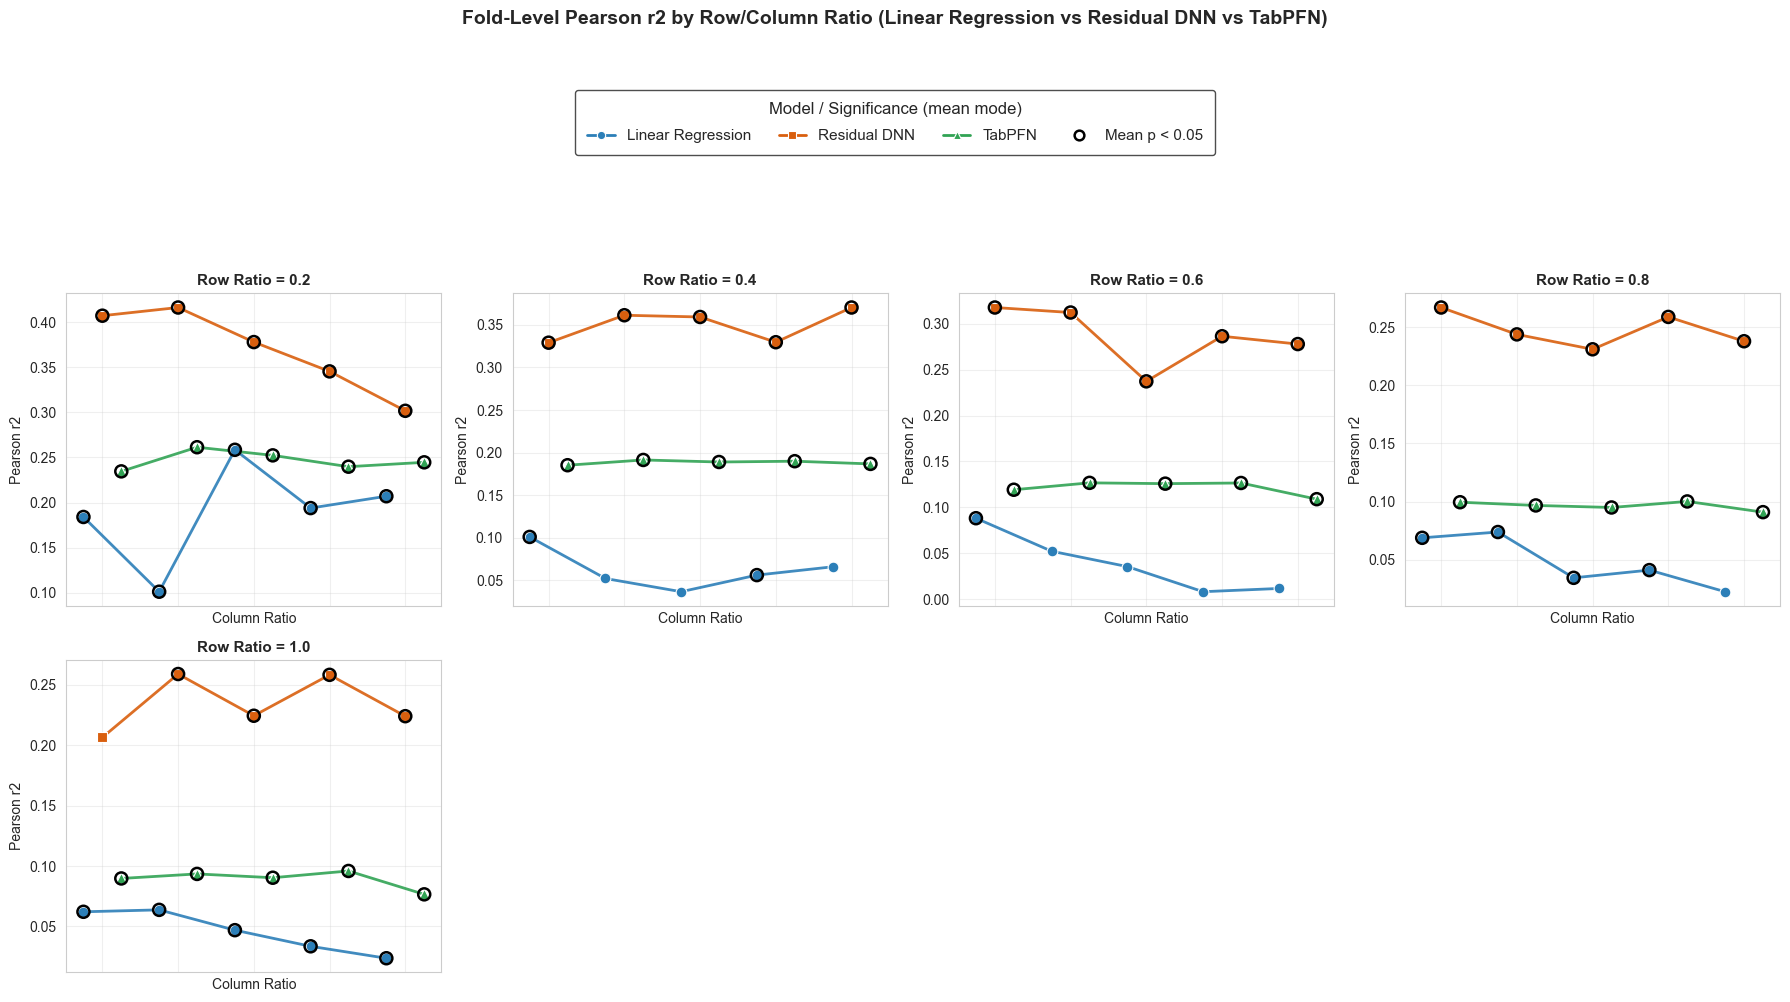

In [243]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Target settings
ROW_RATIOS = [0.2, 0.4, 0.6, 0.8, 1.0]
COL_RATIOS = [0.2, 0.4, 0.6, 0.8, 1.0]
ILLNESS = "SCZ"
P_CLUMP = "0.0001"
DISTRIBUTION = "low"

# Switch between "box" and "mean"
PLOT_MODE = "mean"

RESULTS_ROOT = (project_root / "results").resolve()
MODEL_PREFIXES = {
    "Linear Regression": "linear_regression",
    "Residual DNN": "residual_dnn",
    "TabPFN": "tabpfn",
}
MODEL_COLORS = {
    "Linear Regression": "#2C7FB8",
    "Residual DNN": "#D95F0E",
    "TabPFN": "#31A354",
}


def build_offsets(labels, span=0.10):
    if len(labels) <= 1:
        return {labels[0]: 0.0}
    offset_values = np.linspace(-span / 2, span / 2, len(labels))
    return {label: float(offset_values[i]) for i, label in enumerate(labels)}


def build_markers(labels):
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
    return {label: marker_cycle[i % len(marker_cycle)] for i, label in enumerate(labels)}


def load_latest_hpo(prefix, row_ratio, col_ratio):
    exp_dir = RESULTS_ROOT / f"{prefix}_{ILLNESS}_p{P_CLUMP}_{DISTRIBUTION}_{row_ratio:.1f}_{col_ratio:.1f}"
    if not exp_dir.exists():
        return None

    candidates = sorted(exp_dir.glob("*.json"))
    if not candidates:
        return None

    latest_file = candidates[-1]
    with open(latest_file, "r") as f:
        payload = json.load(f)

    return payload.get("hpo", {})


# Collect fold-level scores and p-values for each model/ratio combination.
# Structure: metric_data[metric][model_label][row_ratio][col_ratio] -> list of fold values
metric_data = {
    "r2_scores": {label: {rr: {} for rr in ROW_RATIOS} for label in MODEL_PREFIXES},
    "pearson_r2_scores": {label: {rr: {} for rr in ROW_RATIOS} for label in MODEL_PREFIXES},
    "pearson_p_values": {label: {rr: {} for rr in ROW_RATIOS} for label in MODEL_PREFIXES},
}

missing = []
for model_label, prefix in MODEL_PREFIXES.items():
    for rr in ROW_RATIOS:
        for cr in COL_RATIOS:
            hpo = load_latest_hpo(prefix, rr, cr)
            if hpo is None:
                missing.append((model_label, rr, cr))
                continue

            r2_vals = hpo.get("r2_scores", [])
            pr2_vals = hpo.get("pearson_r2_scores", [])
            p_vals = hpo.get("pearson_p_values", [])

            metric_data["r2_scores"][model_label][rr][cr] = list(map(float, r2_vals))
            metric_data["pearson_r2_scores"][model_label][rr][cr] = list(map(float, pr2_vals))
            metric_data["pearson_p_values"][model_label][rr][cr] = list(map(float, p_vals))

if missing:
    print(f"Warning: {len(missing)} result combinations were missing and skipped.")


def clean_values(values, pvalues=None):
    values_arr = np.asarray(values, dtype=float)
    if pvalues is None:
        mask = np.isfinite(values_arr)
        return values_arr[mask], None

    pvalues_arr = np.asarray(pvalues, dtype=float)
    mask = np.isfinite(values_arr) & np.isfinite(pvalues_arr)
    return values_arr[mask], pvalues_arr[mask]


def plot_metric(metric_key, title, y_label, p_metric_key="pearson_p_values", plot_mode="box"):
    if plot_mode not in {"box", "mean"}:
        raise ValueError("plot_mode must be 'box' or 'mean'.")

    model_labels = list(MODEL_PREFIXES.keys())
    offsets = build_offsets(model_labels, span=0.10)
    marker_style = build_markers(model_labels)

    n_rows = 3
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True)
    axes = axes.flatten()

    x_vals = np.array(COL_RATIOS, dtype=float)
    xtick_labels = [f"{v:.1f}" for v in COL_RATIOS]
    box_width = 0.045

    for idx, rr in enumerate(ROW_RATIOS):
        ax = axes[idx]

        for model_label in model_labels:
            series_for_model = []
            pvals_for_model = []
            pos_for_model = []
            means = []
            medians = []

            for cr in COL_RATIOS:
                raw_vals = metric_data[metric_key][model_label][rr].get(cr, [])
                raw_pvals = metric_data[p_metric_key][model_label][rr].get(cr, [])
                vals, pvals = clean_values(raw_vals, raw_pvals)
                if len(vals) == 0:
                    continue
                series_for_model.append(vals)
                pvals_for_model.append(pvals)
                pos = float(cr) + offsets[model_label]
                pos_for_model.append(pos)
                means.append(float(np.mean(vals)))
                medians.append(float(np.median(vals)))

            if not series_for_model:
                continue

            if plot_mode == "box":
                bp = ax.boxplot(
                    series_for_model,
                    positions=pos_for_model,
                    widths=box_width,
                    patch_artist=True,
                    showfliers=False,
                    manage_ticks=False,
                )

                for patch in bp["boxes"]:
                    patch.set_facecolor(MODEL_COLORS[model_label])
                    patch.set_alpha(0.35)
                    patch.set_edgecolor(MODEL_COLORS[model_label])
                    patch.set_linewidth(1.5)

                for line in bp["medians"]:
                    line.set_color(MODEL_COLORS[model_label])
                    line.set_linewidth(2.0)

                for whisker in bp["whiskers"]:
                    whisker.set_color(MODEL_COLORS[model_label])
                    whisker.set_linewidth(1.0)

                for cap in bp["caps"]:
                    cap.set_color(MODEL_COLORS[model_label])
                    cap.set_linewidth(1.0)

                ax.plot(
                    pos_for_model,
                    medians,
                    color=MODEL_COLORS[model_label],
                    linewidth=1.5,
                    alpha=0.9,
                )

            else:  # plot_mode == "mean"
                ax.plot(
                    pos_for_model,
                    means,
                    color=MODEL_COLORS[model_label],
                    linewidth=2.0,
                    alpha=0.9,
                )
                ax.scatter(
                    pos_for_model,
                    means,
                    marker=marker_style[model_label],
                    s=60,
                    color=MODEL_COLORS[model_label],
                    edgecolors="white",
                    linewidths=0.8,
                    zorder=5,
                )

            # Add a centered circle if mean p-value across folds is significant.
            y_positions = medians if plot_mode == "box" else means
            for pos, yval, pvals in zip(pos_for_model, y_positions, pvals_for_model):
                if len(pvals) == 0:
                    continue
                mean_p = float(np.mean(pvals))
                if np.isfinite(mean_p) and mean_p < 0.05:
                    ax.scatter(
                        pos,
                        yval,
                        marker="o",
                        s=75,
                        facecolors="none",
                        edgecolors="black",
                        linewidths=1.8,
                        zorder=7,
                    )

        ax.set_title(f"Row Ratio = {rr:.1f}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Column Ratio", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_xticks(x_vals)
        ax.set_xticklabels(xtick_labels)
        ax.grid(True, alpha=0.3)

    for idx in range(len(ROW_RATIOS), len(axes)):
        fig.delaxes(axes[idx])

    legend_handles = []
    for label in model_labels:
        if plot_mode == "box":
            legend_handles.append(
                Patch(
                    facecolor=MODEL_COLORS[label],
                    edgecolor=MODEL_COLORS[label],
                    linewidth=1.8,
                    alpha=0.5,
                    label=label,
                )
            )
        else:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker=marker_style[label],
                    color=MODEL_COLORS[label],
                    markerfacecolor=MODEL_COLORS[label],
                    markeredgecolor="white",
                    markeredgewidth=0.8,
                    linewidth=2.0,
                    markersize=6,
                    label=label,
                )
            )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=1.8,
            markersize=7,
            label="Mean p < 0.05",
        )
    )

    fig.legend(
        handles=legend_handles,
        title=f"Model / Significance ({plot_mode} mode)",
        title_fontsize=12,
        fontsize=11,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        ncol=min(4, len(model_labels) + 1),
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        edgecolor="#444444",
        borderpad=0.8,
        labelspacing=0.8,
        handlelength=1.8,
        handletextpad=0.8,
        columnspacing=1.8,
    )

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.12)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


plot_metric(
    metric_key="r2_scores",
    title="Fold-Level R2 by Row/Column Ratio (Linear Regression vs Residual DNN vs TabPFN)",
    y_label="R2",
    plot_mode=PLOT_MODE,
)

plot_metric(
    metric_key="pearson_r2_scores",
    title="Fold-Level Pearson r2 by Row/Column Ratio (Linear Regression vs Residual DNN vs TabPFN)",
    y_label="Pearson r2",
    plot_mode=PLOT_MODE,
)

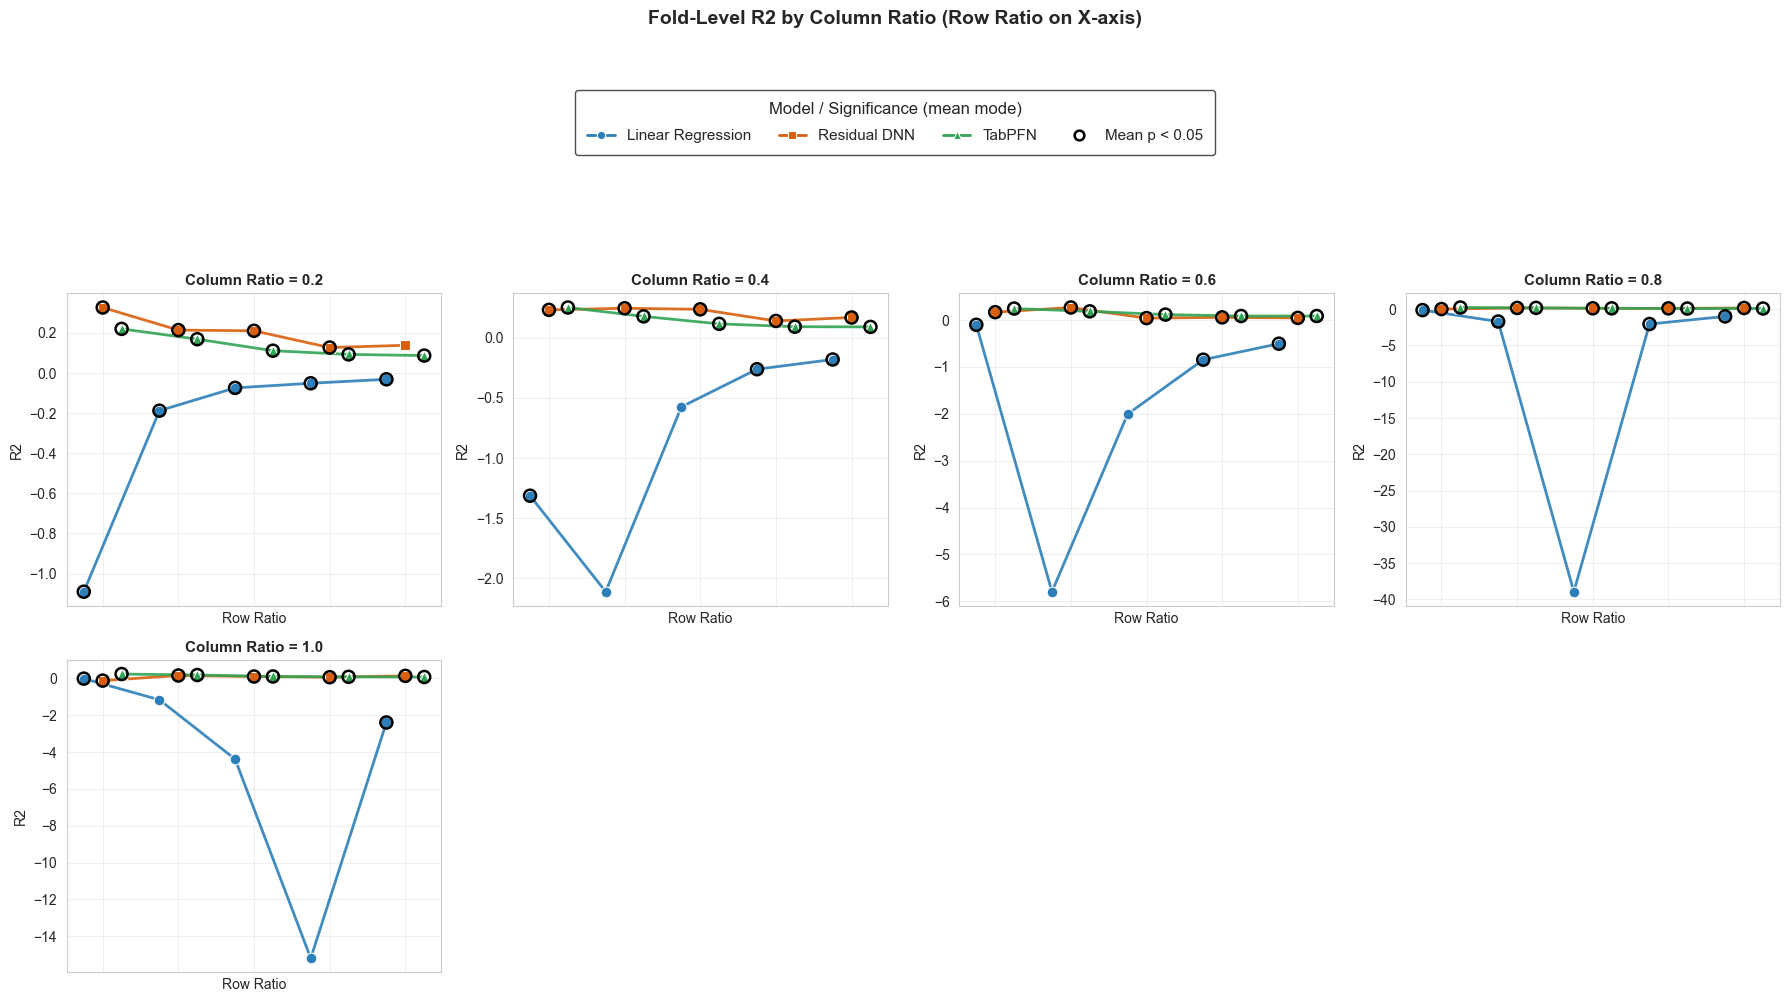

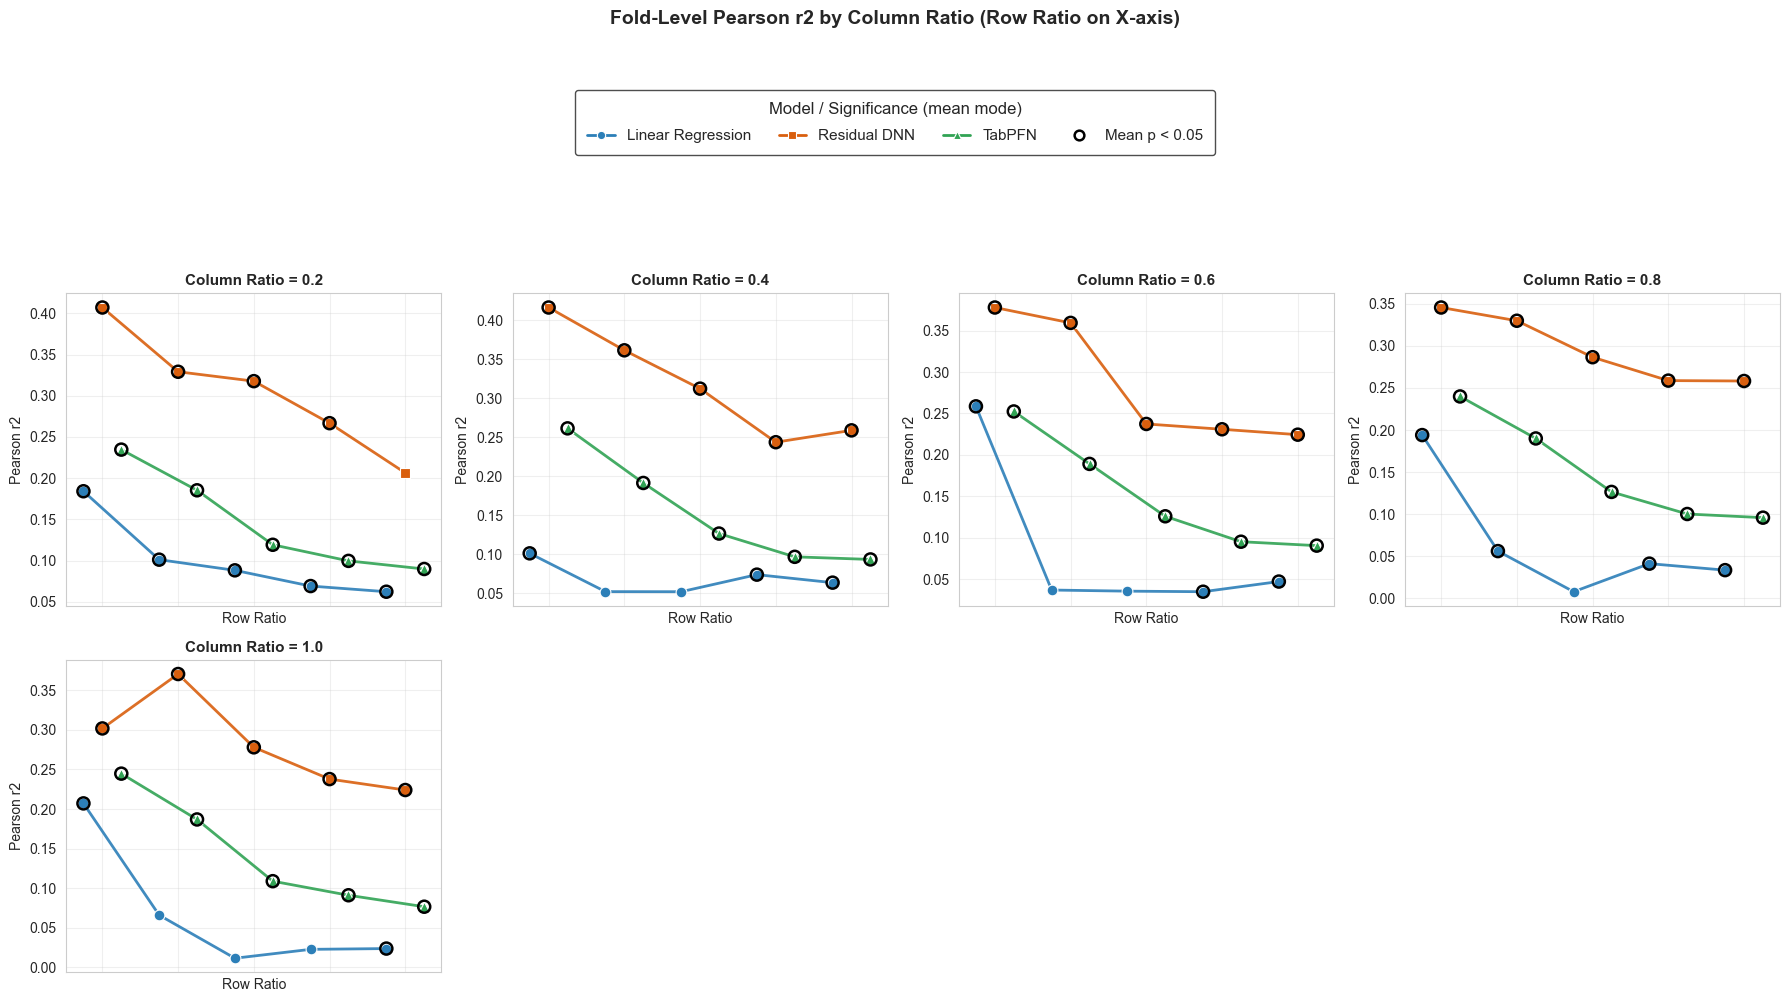

In [244]:
# Reverse layout: one subplot per column ratio, row ratios on x-axis


def plot_metric_by_colratio(metric_key, title, y_label, p_metric_key="pearson_p_values", plot_mode="box"):
    if plot_mode not in {"box", "mean"}:
        raise ValueError("plot_mode must be 'box' or 'mean'.")

    model_labels = list(MODEL_PREFIXES.keys())
    offsets = build_offsets(model_labels, span=0.10)
    marker_style = build_markers(model_labels)

    n_rows = 3
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True)
    axes = axes.flatten()

    x_vals = np.array(ROW_RATIOS, dtype=float)
    xtick_labels = [f"{v:.1f}" for v in ROW_RATIOS]
    box_width = 0.045

    for idx, cr in enumerate(COL_RATIOS):
        ax = axes[idx]

        for model_label in model_labels:
            series_for_model = []
            pvals_for_model = []
            pos_for_model = []
            means = []
            medians = []

            for rr in ROW_RATIOS:
                raw_vals = metric_data[metric_key][model_label][rr].get(cr, [])
                raw_pvals = metric_data[p_metric_key][model_label][rr].get(cr, [])
                vals, pvals = clean_values(raw_vals, raw_pvals)
                if len(vals) == 0:
                    continue
                series_for_model.append(vals)
                pvals_for_model.append(pvals)
                pos = float(rr) + offsets[model_label]
                pos_for_model.append(pos)
                means.append(float(np.mean(vals)))
                medians.append(float(np.median(vals)))

            if not series_for_model:
                continue

            if plot_mode == "box":
                bp = ax.boxplot(
                    series_for_model,
                    positions=pos_for_model,
                    widths=box_width,
                    patch_artist=True,
                    showfliers=False,
                    manage_ticks=False,
                )

                for patch in bp["boxes"]:
                    patch.set_facecolor(MODEL_COLORS[model_label])
                    patch.set_alpha(0.35)
                    patch.set_edgecolor(MODEL_COLORS[model_label])
                    patch.set_linewidth(1.5)

                for line in bp["medians"]:
                    line.set_color(MODEL_COLORS[model_label])
                    line.set_linewidth(2.0)

                for whisker in bp["whiskers"]:
                    whisker.set_color(MODEL_COLORS[model_label])
                    whisker.set_linewidth(1.0)

                for cap in bp["caps"]:
                    cap.set_color(MODEL_COLORS[model_label])
                    cap.set_linewidth(1.0)

                ax.plot(
                    pos_for_model,
                    medians,
                    color=MODEL_COLORS[model_label],
                    linewidth=1.5,
                    alpha=0.9,
                )

            else:  # plot_mode == "mean"
                ax.plot(
                    pos_for_model,
                    means,
                    color=MODEL_COLORS[model_label],
                    linewidth=2.0,
                    alpha=0.9,
                )
                ax.scatter(
                    pos_for_model,
                    means,
                    marker=marker_style[model_label],
                    s=60,
                    color=MODEL_COLORS[model_label],
                    edgecolors="white",
                    linewidths=0.8,
                    zorder=5,
                )

            # Add a centered circle if mean p-value across folds is significant.
            y_positions = medians if plot_mode == "box" else means
            for pos, yval, pvals in zip(pos_for_model, y_positions, pvals_for_model):
                if len(pvals) == 0:
                    continue
                mean_p = float(np.mean(pvals))
                if np.isfinite(mean_p) and mean_p < 0.05:
                    ax.scatter(
                        pos,
                        yval,
                        marker="o",
                        s=75,
                        facecolors="none",
                        edgecolors="black",
                        linewidths=1.8,
                        zorder=7,
                    )

        ax.set_title(f"Column Ratio = {cr:.1f}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Row Ratio", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_xticks(x_vals)
        ax.set_xticklabels(xtick_labels)
        ax.grid(True, alpha=0.3)

    for idx in range(len(COL_RATIOS), len(axes)):
        fig.delaxes(axes[idx])

    legend_handles = []
    for label in model_labels:
        if plot_mode == "box":
            legend_handles.append(
                Patch(
                    facecolor=MODEL_COLORS[label],
                    edgecolor=MODEL_COLORS[label],
                    linewidth=1.8,
                    alpha=0.5,
                    label=label,
                )
            )
        else:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker=marker_style[label],
                    color=MODEL_COLORS[label],
                    markerfacecolor=MODEL_COLORS[label],
                    markeredgecolor="white",
                    markeredgewidth=0.8,
                    linewidth=2.0,
                    markersize=6,
                    label=label,
                )
            )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=1.8,
            markersize=7,
            label="Mean p < 0.05",
        )
    )

    fig.legend(
        handles=legend_handles,
        title=f"Model / Significance ({plot_mode} mode)",
        title_fontsize=12,
        fontsize=11,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        ncol=min(4, len(model_labels) + 1),
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        edgecolor="#444444",
        borderpad=0.8,
        labelspacing=0.8,
        handlelength=1.8,
        handletextpad=0.8,
        columnspacing=1.8,
    )

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.12)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


plot_metric_by_colratio(
    metric_key="r2_scores",
    title="Fold-Level R2 by Column Ratio (Row Ratio on X-axis)",
    y_label="R2",
    plot_mode=PLOT_MODE,
)

plot_metric_by_colratio(
    metric_key="pearson_r2_scores",
    title="Fold-Level Pearson r2 by Column Ratio (Row Ratio on X-axis)",
    y_label="Pearson r2",
    plot_mode=PLOT_MODE,
)